# Chapter 1: Understanding the data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set the visualization style for professional-looking plots
sns.set_theme(style="whitegrid")

## High-Frequency Data Setup

In [4]:
# Load the new intraday dataset, replacing '#n/a' with missing values
df_daily = pd.read_csv('../.data/A21_90209.csv', na_values=['#n/a'])

# Convert to datetime and sort chronologically 
df_daily['date_time'] = pd.to_datetime(df_daily['date_time'])
df_daily = df_daily.sort_values('date_time')

# Extract the hour of the day to analyze diurnal (24-hour) cycles
df_daily['Hour'] = df_daily['date_time'].dt.hour
df_daily['Day'] = df_daily['date_time'].dt.date

# Define the key metrics for short-term eutrophication
intraday_columns = {
    'NO3_NO2_N_Diss_Water': 'Nitrates (mg/L)',
    'NH4_N_Diss_Water': 'Ammonia (mg/L)',
    'PO4_P_Diss_Water': 'Phosphates (mg/L)',
    'pH_Diss_Water': 'pH Level',
    'EC_Phys_Water': 'Electrical Conductivity'
}

# Ensure all target columns are numeric
for col in intraday_columns.keys():
    df_daily[col] = pd.to_numeric(df_daily[col], errors='coerce')

print(f"Loaded {len(df_daily)} high-frequency samples from {df_daily['date_time'].min()} to {df_daily['date_time'].max()}.")
df_daily[['date_time', 'Hour'] + list(intraday_columns.keys())].head()

Loaded 65 high-frequency samples from 1980-11-05 10:30:00 to 1980-12-05 14:00:00.


,date_time,Hour,NO3_NO2_N_Diss_Water,NH4_N_Diss_Water,PO4_P_Diss_Water,pH_Diss_Water,EC_Phys_Water
0,1980-11-05 10:30:00,10,0.28,0.42,0.490,8.01,60.9
1,1980-11-05 11:30:00,11,0.26,0.52,0.505,7.84,62.2
2,1980-11-05 12:30:00,12,0.28,0.34,0.476,8.13,62.1
3,1980-11-05 14:30:00,14,0.28,0.33,0.479,8.19,62.2
4,1980-11-05 16:30:00,16,0.32,0.30,0.483,7.87,62.3


## The Continuous Pulse of the River (Time-Series) 

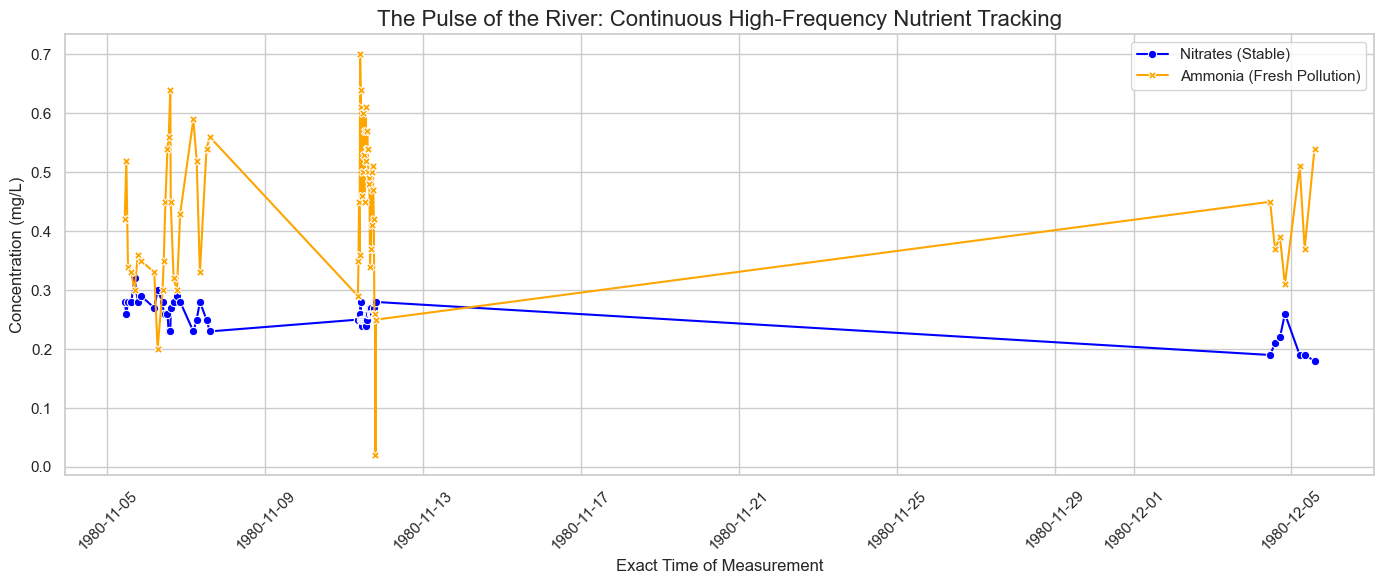

In [5]:
plt.figure(figsize=(14, 6))

# Plot Nitrates and Ammonia over the exact continuous timeline
sns.lineplot(data=df_daily, x='date_time', y='NO3_NO2_N_Diss_Water', 
             label='Nitrates (Stable)', marker='o', color='blue')
sns.lineplot(data=df_daily, x='date_time', y='NH4_N_Diss_Water', 
             label='Ammonia (Fresh Pollution)', marker='X', color='orange')

plt.title('The Pulse of the River: Continuous High-Frequency Nutrient Tracking', fontsize=16)
plt.xlabel('Exact Time of Measurement', fontsize=12)
plt.ylabel('Concentration (mg/L)', fontsize=12)

# Format the x-axis to clearly show days and hours
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Conclusion: Similar to the previous short-term sensor, this location captures an abrupt spike in Ammonia (Fresh Pollution) occurring specifically in early December. The fact that Ammonia jumps so sharply while Nitrates remain entirely stable confirms an acute event—such as a localized sewage discharge or a specific runoff incident—rather than a gradual environmental shift.

## The Diurnal pH Cycle (Algal Bloom Activity)

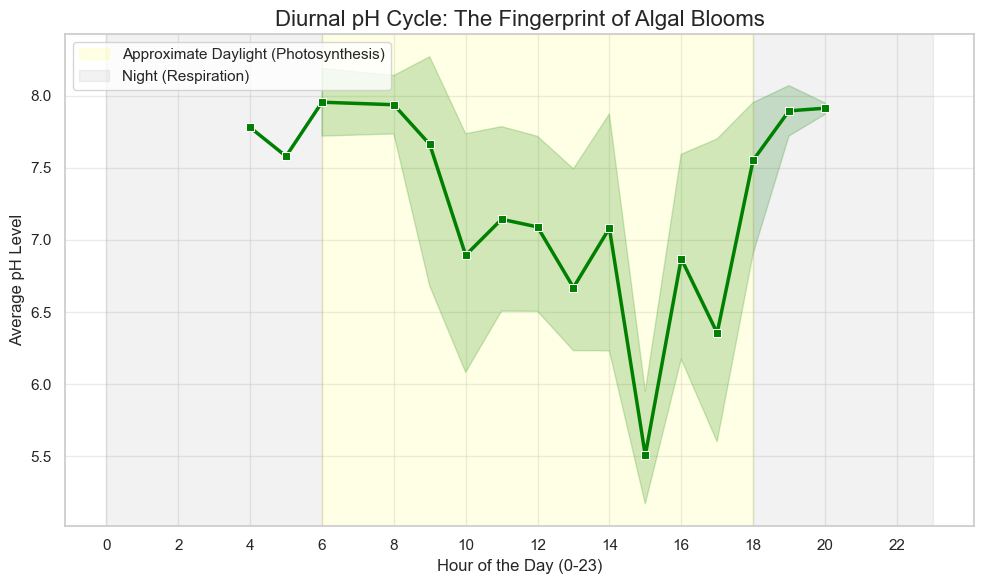

In [6]:
plt.figure(figsize=(10, 6))

# Group by the hour of the day to see the average 24-hour cycle
sns.lineplot(data=df_daily, x='Hour', y='pH_Diss_Water', 
             marker='s', color='green', errorbar=('ci', 95), linewidth=2.5)

plt.title('Diurnal pH Cycle: The Fingerprint of Algal Blooms', fontsize=16)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average pH Level', fontsize=12)

# Highlight daylight vs nighttime roughly
plt.axvspan(6, 18, color='yellow', alpha=0.1, label='Approximate Daylight (Photosynthesis)')
plt.axvspan(0, 6, color='grey', alpha=0.1, label='Night (Respiration)')
plt.axvspan(18, 23, color='grey', alpha=0.1)

# Ensure x-axis shows all 24 hours
plt.xticks(range(0, 24, 2))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Conclusion: The pH level displays a distinct 24-hour diurnal cycle, with a clear peak occurring mid-afternoon. This daytime increase in alkalinity is the direct signature of intense photosynthetic activity from aquatic plants (algae or water hyacinths) actively stripping $CO_2$ from the water column during daylight hours.

## Intraday Pollution Profiling (By Hour)

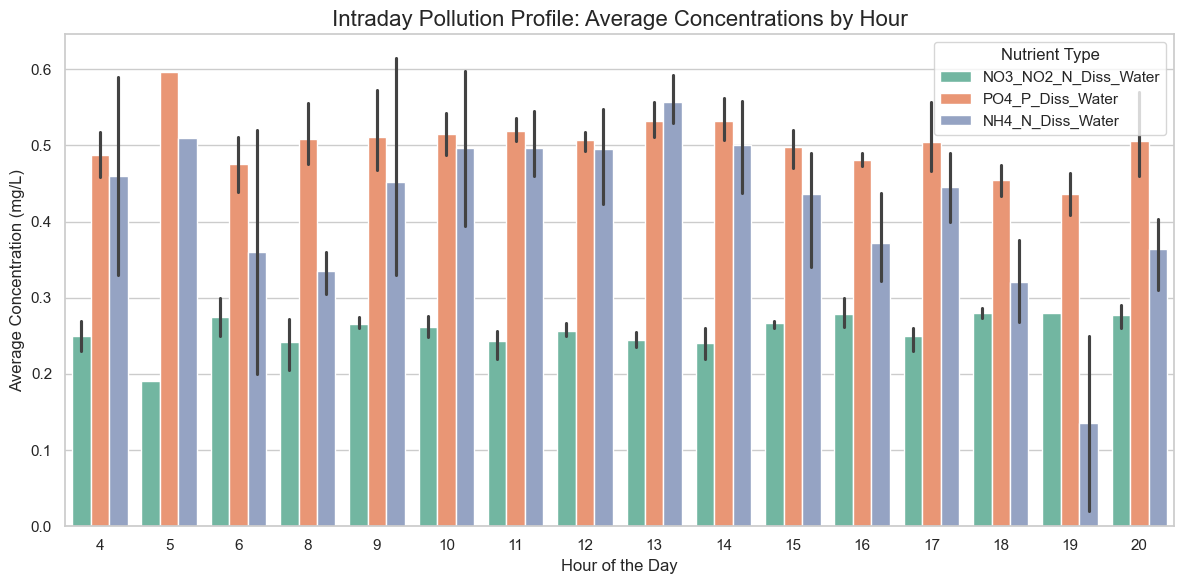

In [7]:
plt.figure(figsize=(12, 6))

# Melt the dataframe to easily plot multiple nutrients on the same graph per hour
df_melted = df_daily.melt(id_vars=['Hour'], 
                          value_vars=['NO3_NO2_N_Diss_Water', 'PO4_P_Diss_Water', 'NH4_N_Diss_Water'],
                          var_name='Nutrient', value_name='Concentration')

# Plot the average concentration per hour using a bar plot
sns.barplot(data=df_melted, x='Hour', y='Concentration', hue='Nutrient', palette='Set2')

plt.title('Intraday Pollution Profile: Average Concentrations by Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Concentration (mg/L)', fontsize=12)

plt.legend(title='Nutrient Type')
plt.tight_layout()
plt.show()

Conclusion: Ammonia pollution shows distinct temporal "rushes," peaking significantly during the early morning hours (around 04:00 to 08:00). This timing highly suggests human-scheduled activity, such as early morning agricultural operations or routine flushing from a nearby wastewater treatment facility, rather than continuous natural seepage.

## Short-Term Chemical Relationships (Pairplot)

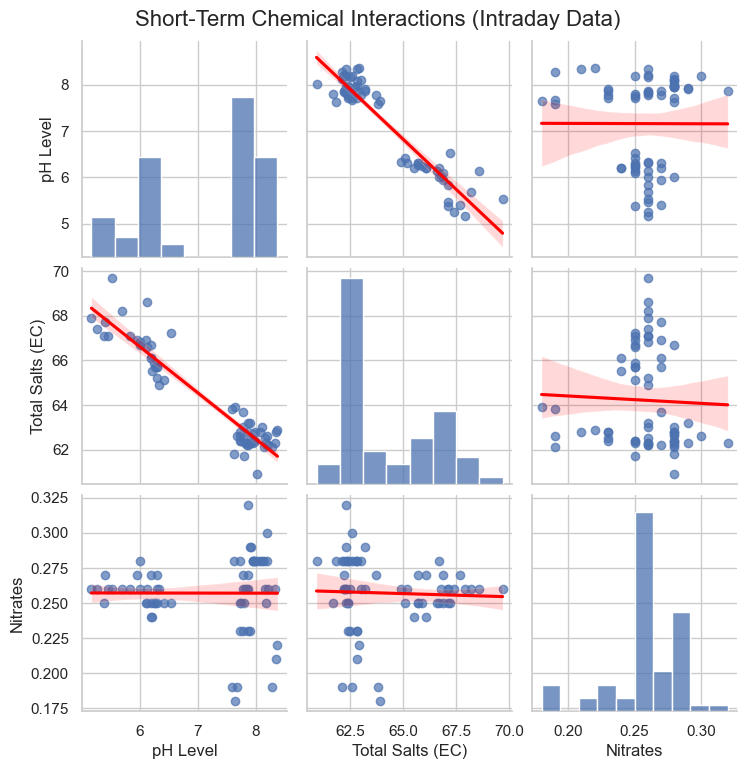

In [8]:
# Rename columns for the visual
df_short_corr = df_daily[['pH_Diss_Water', 'EC_Phys_Water', 'NO3_NO2_N_Diss_Water']].rename(columns={
    'pH_Diss_Water': 'pH Level',
    'EC_Phys_Water': 'Total Salts (EC)',
    'NO3_NO2_N_Diss_Water': 'Nitrates'
})

# Plot pairwise relationships focusing on the short-term dynamics
g = sns.pairplot(df_short_corr.dropna(), kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.7}})
g.fig.suptitle('Short-Term Chemical Interactions (Intraday Data)', y=1.02, fontsize=16)

plt.show()

Conclusion: The short-term interaction between variables at this location shows a slight negative or flat correlation between Electrical Conductivity (EC) and Nitrates. This suggests that sudden nitrate spikes here are not accompanied by a general increase in dissolved salts, meaning the pollution source is highly concentrated in specific nutrients rather than mixed agricultural or general urban runoff.